In [1]:
import torch
import matplotlib.pyplot as plt

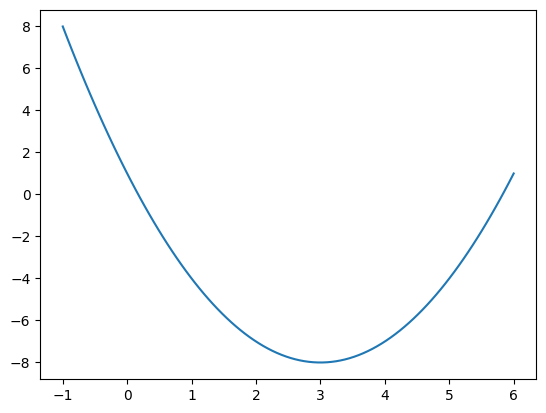

In [3]:
def f(x):
    return x**2 - 6*x + 1

def f_prime(x):
    return 2*x - 6

X = torch.linspace(-1, 6, 100)
plt.plot(X, f(X))

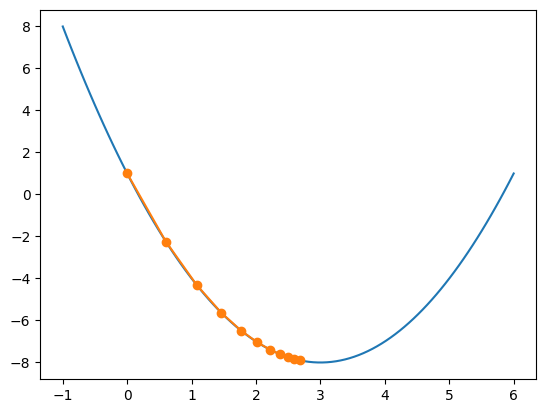

In [11]:
x_iters = [0]
for i in range(10):
    x = x_iters[-1]
    x_new = x - 0.1 * f_prime(x)
    x_iters.append(x_new)
x_iters = torch.tensor(x_iters)

plt.figure()
plt.plot(X, f(X))
plt.plot(x_iters, f(x_iters), '-o')

In [12]:
def f(x1, x2):
    return 2*x1**2 + 3*x2**2 - 2*x1*x2 - 3*x1 + 5*x2 + 4

def df_dx1(x1, x2):
    return 4*x1 - 2*x2 - 3

def df_dx2(x1, x2):
    return 6*x2 - 2*x1 + 5

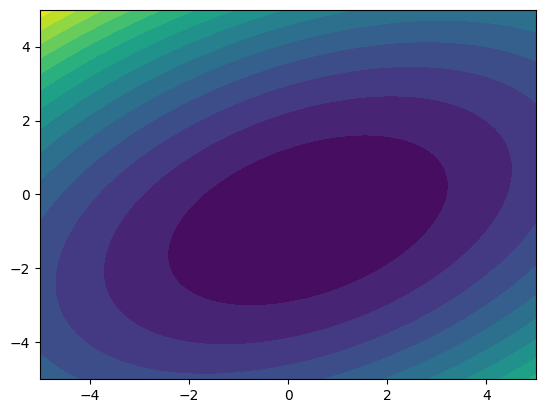

In [14]:
X1, X2 = torch.meshgrid(torch.linspace(-5, 5, 100), torch.linspace(-5, 5, 100))
plt.contourf(X1, X2, f(X1, X2), levels=20)

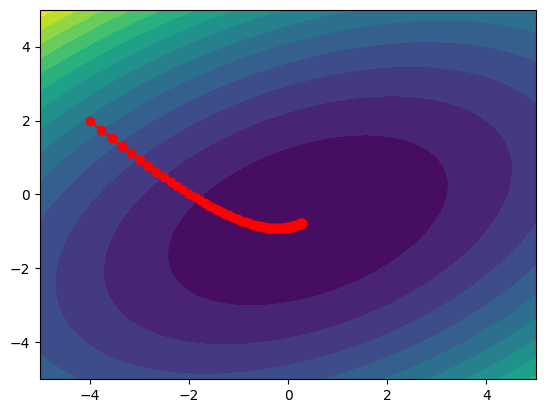

In [17]:
x_iters = [torch.tensor([-4, 2])]
eta = 0.01
for i in range(100):
    x1, x2 = x_iters[-1]
    x1_new = x1 - eta * df_dx1(x1, x2)
    x2_new = x2 - eta * df_dx2(x1, x2)
    x_iters.append(torch.tensor([x1_new, x2_new]))
x_iters = torch.stack(x_iters, dim=1)

plt.figure()
plt.contourf(X1, X2, f(X1, X2), levels=20)
plt.plot(x_iters[0], x_iters[1], 'r-o')

In [18]:
f(1., 2.), df_dx1(1., 2.), df_dx2(1., 2.)

(21.0, -3.0, 15.0)

In [19]:
x = torch.tensor([1., 2.], requires_grad=True)
f(x[0], x[1]).backward()
x.grad

tensor([-3., 15.])